# 0. Configuration — Imports et paramètres globaux

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("pandas  :", pd.__version__)
print("numpy   :", np.__version__)
print("matplotlib :", plt.matplotlib.__version__)
print("Tout est prêt !")

pandas  : 3.0.2
numpy   : 2.4.4
matplotlib : 3.10.8
Tout est prêt !


# 1. Chargement des données — Dataset COVID-19 Johns Hopkins

In [2]:
BASE = "https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/"
PATH = "csse_covid_19_data/csse_covid_19_time_series/"

confirmed = pd.read_csv(BASE + PATH + "time_series_covid19_confirmed_global.csv")
deaths    = pd.read_csv(BASE + PATH + "time_series_covid19_deaths_global.csv")
recovered = pd.read_csv(BASE + PATH + "time_series_covid19_recovered_global.csv")

print("Confirmed :", confirmed.shape)
print("Deaths    :", deaths.shape)
print("Recovered :", recovered.shape)
print("Téléchargement réussi !")

Confirmed : (289, 1147)
Deaths    : (289, 1147)
Recovered : (274, 1147)
Téléchargement réussi !


In [3]:
print("=== CONFIRMED ===")
print(confirmed.head(3))
print("\nColonnes :", confirmed.columns[:8].tolist(), "...")

=== CONFIRMED ===
  Province/State Country/Region       Lat       Long  1/22/20  1/23/20  \
0            NaN    Afghanistan  33.93911  67.709953        0        0   
1            NaN        Albania  41.15330  20.168300        0        0   
2            NaN        Algeria  28.03390   1.659600        0        0   

   1/24/20  1/25/20  1/26/20  1/27/20  ...  2/28/23  3/1/23  3/2/23  3/3/23  \
0        0        0        0        0  ...   209322  209340  209358  209362   
1        0        0        0        0  ...   334391  334408  334408  334427   
2        0        0        0        0  ...   271441  271448  271463  271469   

   3/4/23  3/5/23  3/6/23  3/7/23  3/8/23  3/9/23  
0  209369  209390  209406  209436  209451  209451  
1  334427  334427  334427  334427  334443  334457  
2  271469  271477  271477  271490  271494  271496  

[3 rows x 1147 columns]

Colonnes : ['Province/State', 'Country/Region', 'Lat', 'Long', '1/22/20', '1/23/20', '1/24/20', '1/25/20'] ...


In [4]:
print("=== VALEURS MANQUANTES ===")
print("\nConfirmed :")
print(confirmed.isnull().sum().head(6))
print("\nDeaths :")
print(deaths.isnull().sum().head(6))
print("\nRecovered :")
print(recovered.isnull().sum().head(6))

=== VALEURS MANQUANTES ===

Confirmed :
Province/State    198
Country/Region      0
Lat                 2
Long                2
1/22/20             0
1/23/20             0
dtype: int64

Deaths :
Province/State    198
Country/Region      0
Lat                 2
Long                2
1/22/20             0
1/23/20             0
dtype: int64

Recovered :
Province/State    199
Country/Region      0
Lat                 1
Long                1
1/22/20             0
1/23/20             0
dtype: int64


# 2. Nettoyage et restructuration des données

In [5]:
# Maintenant chaque ligne = un pays + une date + une valeur
def nettoyer(df, nom_colonne):
    # Supprimer les colonnes inutiles
    df = df.drop(columns=["Province/State", "Lat", "Long"])
    # Agréger par pays (sommer les régions)
    df = df.groupby("Country/Region").sum().reset_index()
    # Pivoter en format long (une ligne par date)
    df = df.melt(id_vars="Country/Region", var_name="date", value_name=nom_colonne)
    # Convertir la colonne date en datetime
    df["date"] = pd.to_datetime(df["date"])
    return df

df_confirmed = nettoyer(confirmed, "confirmed")
df_deaths    = nettoyer(deaths,    "deaths")
df_recovered = nettoyer(recovered, "recovered")

print("Confirmed :", df_confirmed.shape)
print(df_confirmed.head(5))

C:\Users\DELL\AppData\Local\Temp\ipykernel_4624\2208368664.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df = df.groupby("Country/Region").sum().reset_index()
C:\Users\DELL\AppData\Local\Temp\ipykernel_4624\2208368664.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["date"] = pd.to_datetime(df["date"])
C:\Users\DELL\AppData\Local\Temp\ipykernel_4624\2208368664.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame

Confirmed : (229743, 3)
  Country/Region       date  confirmed
0    Afghanistan 2020-01-22          0
1        Albania 2020-01-22          0
2        Algeria 2020-01-22          0
3        Andorra 2020-01-22          0
4         Angola 2020-01-22          0


C:\Users\DELL\AppData\Local\Temp\ipykernel_4624\2208368664.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["date"] = pd.to_datetime(df["date"])


In [6]:
# Fusion des trois tableaux en un seul
df = df_confirmed.merge(df_deaths,    on=["Country/Region", "date"]) \
                 .merge(df_recovered, on=["Country/Region", "date"])

# Trier par pays puis par date
df = df.sort_values(["Country/Region", "date"]).reset_index(drop=True)

print("Shape final :", df.shape)
print(df.head(5))

Shape final : (229743, 5)
  Country/Region       date  confirmed  deaths  recovered
0    Afghanistan 2020-01-22          0       0          0
1    Afghanistan 2020-01-23          0       0          0
2    Afghanistan 2020-01-24          0       0          0
3    Afghanistan 2020-01-25          0       0          0
4    Afghanistan 2020-01-26          0       0          0


# 3. Sélection du pays — Algérie

In [7]:
# Filtrer uniquement l'Algérie
df_algerie = df[df["Country/Region"] == "Algeria"].copy()
df_algerie = df_algerie.sort_values("date").reset_index(drop=True)

print("Nombre de jours :", len(df_algerie))
print("Période : du", df_algerie["date"].min(), "au", df_algerie["date"].max())
print(df_algerie.head(5))

Nombre de jours : 1143
Période : du 2020-01-22 00:00:00 au 2023-03-09 00:00:00
  Country/Region       date  confirmed  deaths  recovered
0        Algeria 2020-01-22          0       0          0
1        Algeria 2020-01-23          0       0          0
2        Algeria 2020-01-24          0       0          0
3        Algeria 2020-01-25          0       0          0
4        Algeria 2020-01-26          0       0          0


In [8]:
# Calculer les nouveaux cas journaliers (différence entre chaque jour)
df_algerie["new_cases"]    = df_algerie["confirmed"].diff().fillna(0).clip(lower=0)
df_algerie["new_deaths"]   = df_algerie["deaths"].diff().fillna(0).clip(lower=0)
df_algerie["new_recovered"]= df_algerie["recovered"].diff().fillna(0).clip(lower=0)

print(df_algerie[["date", "confirmed", "new_cases", "new_deaths"]].head(10))

        date  confirmed  new_cases  new_deaths
0 2020-01-22          0        0.0         0.0
1 2020-01-23          0        0.0         0.0
2 2020-01-24          0        0.0         0.0
3 2020-01-25          0        0.0         0.0
4 2020-01-26          0        0.0         0.0
5 2020-01-27          0        0.0         0.0
6 2020-01-28          0        0.0         0.0
7 2020-01-29          0        0.0         0.0
8 2020-01-30          0        0.0         0.0
9 2020-01-31          0        0.0         0.0


In [9]:
# Trouver le premier jour avec des cas en Algérie
premier_cas = df_algerie[df_algerie["new_cases"] > 0].iloc[0]
print("Premier cas en Algérie :")
print(premier_cas[["date", "new_cases", "confirmed"]])

Premier cas en Algérie :
date         2020-02-25 00:00:00
new_cases                    1.0
confirmed                      1
Name: 34, dtype: object


In [10]:
print("=== FORME DU DATASET ===")
print("Lignes x Colonnes :", df_algerie.shape)

print("\n=== COLONNES ET TYPES ===")
print(df_algerie.dtypes)

print("\n=== APERÇU GÉNÉRAL ===")
print(df_algerie.describe())

print("\n=== 5 PREMIÈRES LIGNES ===")
print(df_algerie.head())

print("\n=== 5 DERNIÈRES LIGNES ===")
print(df_algerie.tail())

=== FORME DU DATASET ===
Lignes x Colonnes : (1143, 8)

=== COLONNES ET TYPES ===
Country/Region               str
date              datetime64[us]
confirmed                  int64
deaths                     int64
recovered                  int64
new_cases                float64
new_deaths               float64
new_recovered            float64
dtype: object

=== APERÇU GÉNÉRAL ===
                      date      confirmed       deaths      recovered  \
count                 1143    1143.000000  1143.000000    1143.000000   
mean   2021-08-15 00:00:00  159878.958880  4288.079615   22458.646544   
min    2020-01-22 00:00:00       0.000000     0.000000       0.000000   
25%    2020-11-02 12:00:00   58776.500000  1980.000000       0.000000   
50%    2021-08-15 00:00:00  187258.000000  4794.000000       0.000000   
75%    2022-05-27 12:00:00  265871.500000  6875.000000   38703.000000   
max    2023-03-09 00:00:00  271496.000000  6881.000000  118409.000000   
std                    NaN  1007

# 4. Visualisation EDA — Algérie

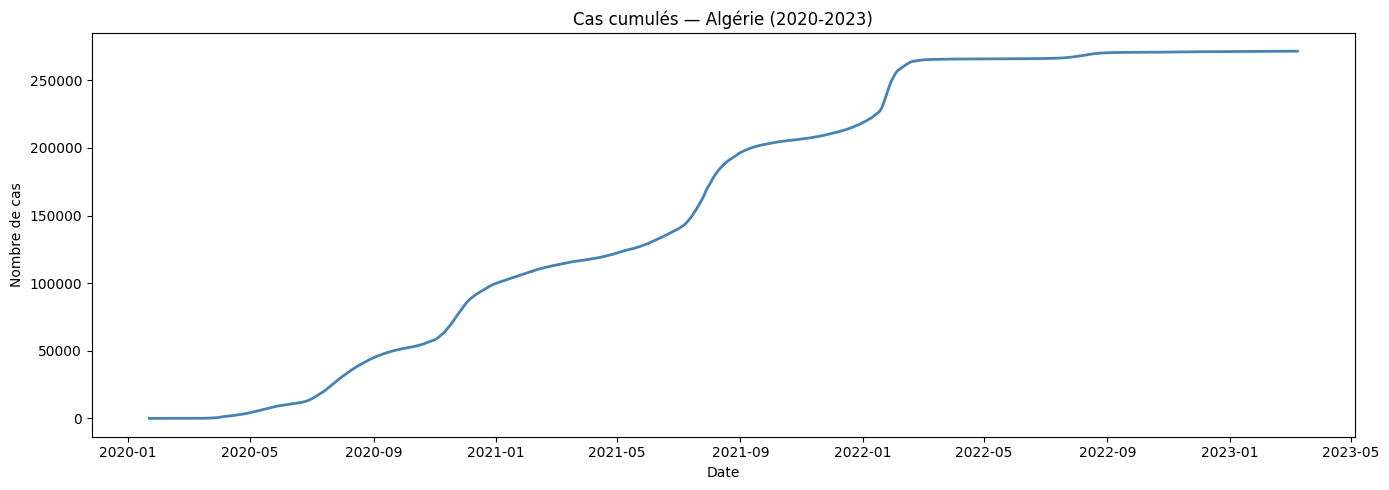

In [11]:
# Graphique 1 : Cas cumulés
plt.figure(figsize=(14, 5))
plt.plot(df_algerie["date"], df_algerie["confirmed"], color="steelblue", linewidth=2)
plt.title("Cas cumulés — Algérie (2020-2023)")
plt.xlabel("Date")
plt.ylabel("Nombre de cas")
plt.tight_layout()
plt.savefig("../outputs/1_cas_cumules.png", dpi=150)
plt.show()

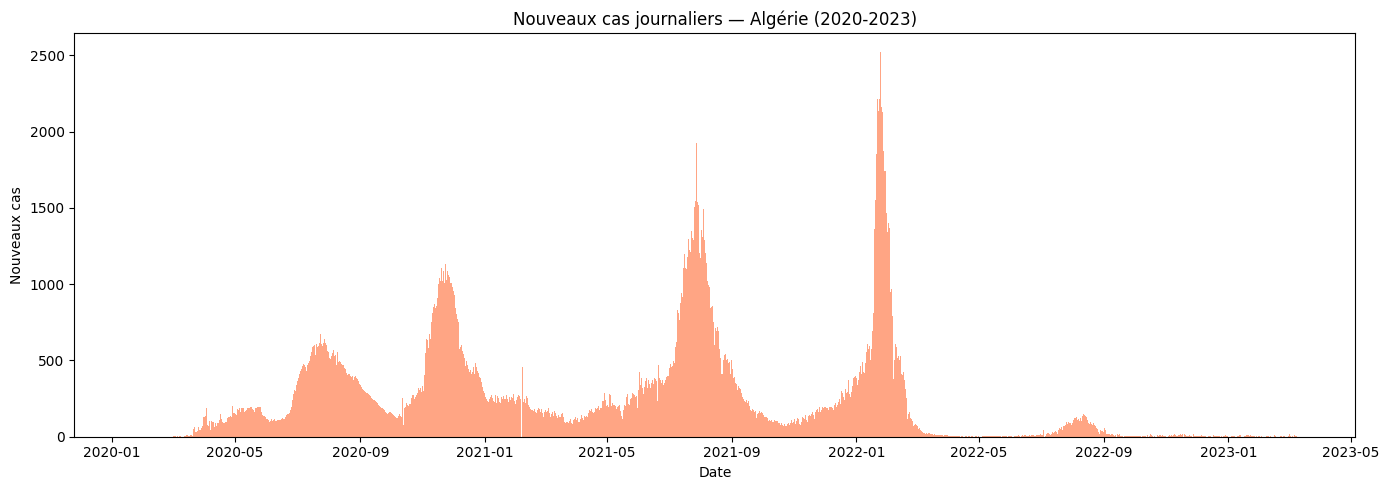

In [12]:
# Graphique 2 : Nouveaux cas journaliers
plt.figure(figsize=(14, 5))
plt.bar(df_algerie["date"], df_algerie["new_cases"], 
        color="coral", width=1, alpha=0.7)
plt.title("Nouveaux cas journaliers — Algérie (2020-2023)")
plt.xlabel("Date")
plt.ylabel("Nouveaux cas")
plt.tight_layout()
plt.savefig("../outputs/2_nouveaux_cas.png", dpi=150)
plt.show()

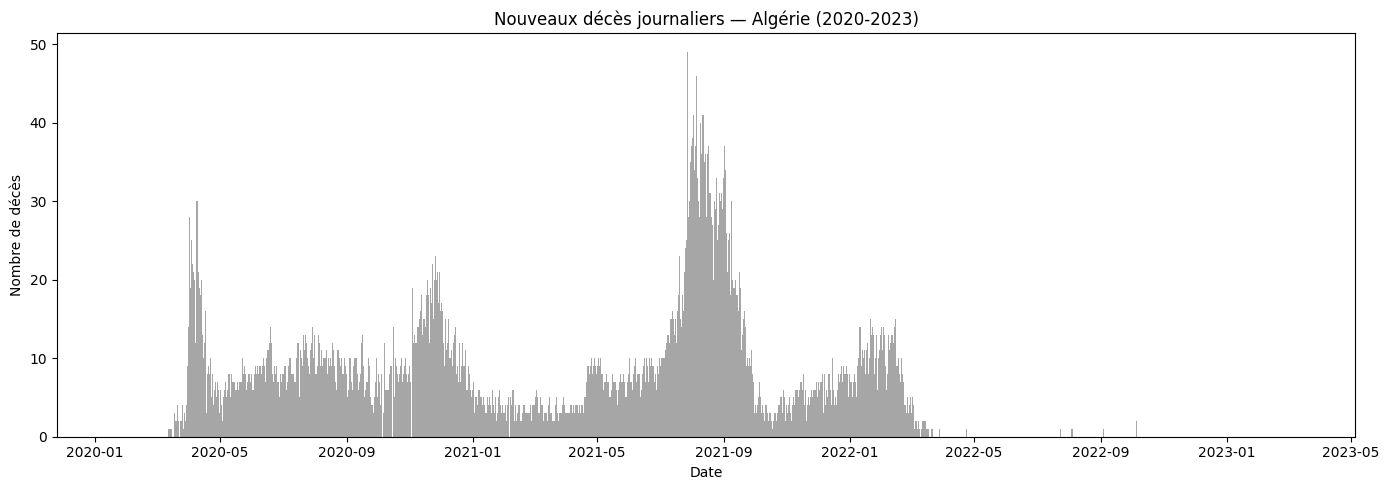

In [13]:
# Graphique 4 : Nouveaux décès journaliers (sans moyenne mobile)
plt.figure(figsize=(14, 5))
plt.bar(df_algerie["date"], df_algerie["new_deaths"],
        color="gray", width=1, alpha=0.7, label="Décès journaliers")
plt.title("Nouveaux décès journaliers — Algérie (2020-2023)")
plt.xlabel("Date")
plt.ylabel("Nombre de décès")
plt.tight_layout()
plt.savefig("../outputs/4_deces.png", dpi=150)
plt.show()

# JOUR 2 — Feature Engineering & Préparation LSTM

## 0. Seeds aléatoires — À exécuter en premier

In [14]:
import random
import os

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

print("Seeds fixées avec succès — valeur :", SEED)

Seeds fixées avec succès — valeur : 42


## 1. Création des features supplémentaires

In [15]:
# Moyenne mobile 7 jours
df_algerie["new_cases_7d"] = df_algerie["new_cases"].rolling(7).mean()

# Taux de croissance journalier
df_algerie["growth_rate"] = df_algerie["confirmed"].pct_change().fillna(0).clip(-1, 5)

# Jour de la semaine (0=lundi, 6=dimanche)
df_algerie["day_of_week"] = df_algerie["date"].dt.dayofweek

# Lag features (valeurs des jours précédents)
df_algerie["lag_1"] = df_algerie["new_cases_7d"].shift(1)
df_algerie["lag_3"] = df_algerie["new_cases_7d"].shift(3)
df_algerie["lag_7"] = df_algerie["new_cases_7d"].shift(7)

# Supprimer les lignes avec NaN créées par les lags
df_algerie = df_algerie.dropna().reset_index(drop=True)

print("Shape après feature engineering :", df_algerie.shape)
print("\nColonnes disponibles :")
print(df_algerie.columns.tolist())
print("\nAperçu :")
print(df_algerie[["date", "new_cases_7d", "growth_rate", "day_of_week", "lag_1", "lag_3", "lag_7"]].head())

Shape après feature engineering : (1130, 14)

Colonnes disponibles :
['Country/Region', 'date', 'confirmed', 'deaths', 'recovered', 'new_cases', 'new_deaths', 'new_recovered', 'new_cases_7d', 'growth_rate', 'day_of_week', 'lag_1', 'lag_3', 'lag_7']

Aperçu :
        date  new_cases_7d  growth_rate  day_of_week  lag_1  lag_3  lag_7
0 2020-02-04           0.0          0.0            1    0.0    0.0    0.0
1 2020-02-05           0.0          0.0            2    0.0    0.0    0.0
2 2020-02-06           0.0          0.0            3    0.0    0.0    0.0
3 2020-02-07           0.0          0.0            4    0.0    0.0    0.0
4 2020-02-08           0.0          0.0            5    0.0    0.0    0.0


## 2. Normalisation des données

In [16]:
from sklearn.preprocessing import MinMaxScaler
import joblib

# Les 6 features qu'on va utiliser
FEATURES = ["new_cases_7d", "growth_rate", "day_of_week", "lag_1", "lag_3", "lag_7"]
TARGET    = "new_cases_7d"

print("Features utilisées :", FEATURES)
print("Variable cible :", TARGET)
print("\nAperçu des features avant normalisation :")
print(df_algerie[FEATURES].describe())

Features utilisées : ['new_cases_7d', 'growth_rate', 'day_of_week', 'lag_1', 'lag_3', 'lag_7']
Variable cible : new_cases_7d

Aperçu des features avant normalisation :
       new_cases_7d  growth_rate  day_of_week        lag_1        lag_3  \
count   1130.000000  1130.000000  1130.000000  1130.000000  1130.000000   
mean     240.249305     0.017471     2.997345   240.245133   240.233123   
std      328.258444     0.169987     1.999334   328.261470   328.270143   
min        0.000000     0.000000     0.000000     0.000000     0.000000   
25%        8.750000     0.000041     1.000000     8.750000     8.750000   
50%      141.500000     0.001369     3.000000   141.500000   141.500000   
75%      308.428571     0.005352     5.000000   308.428571   308.428571   
max     2177.571429     5.000000     6.000000  2177.571429  2177.571429   

             lag_7  
count  1130.000000  
mean    240.215803  
std     328.282698  
min       0.000000  
25%       8.750000  
50%     141.500000  
75%     3

In [17]:
# Créer le scaler et normaliser
scaler = MinMaxScaler()

# Fit UNIQUEMENT sur les données (on fittera plus tard sur train seulement)
data = df_algerie[FEATURES].values

print("Forme des données :", data.shape)
print("\nAvant normalisation — première ligne :")
print(data[0])

Forme des données : (1130, 6)

Avant normalisation — première ligne :
[0. 0. 1. 0. 0. 0.]


In [18]:
# Taille des ensembles
n = len(data)
n_train = int(n * 0.70)
n_val   = int(n * 0.85)

print("Total jours      :", n)
print("Train            :", n_train, "jours")
print("Validation       :", n_val - n_train, "jours")
print("Test             :", n - n_val, "jours")
print("\nTrain : du", df_algerie["date"].iloc[0].date(), 
      "au", df_algerie["date"].iloc[n_train-1].date())
print("Val   : du", df_algerie["date"].iloc[n_train].date(), 
      "au", df_algerie["date"].iloc[n_val-1].date())
print("Test  : du", df_algerie["date"].iloc[n_val].date(), 
      "au", df_algerie["date"].iloc[-1].date())

Total jours      : 1130
Train            : 791 jours
Validation       : 169 jours
Test             : 170 jours

Train : du 2020-02-04 au 2022-04-04
Val   : du 2022-04-05 au 2022-09-20
Test  : du 2022-09-21 au 2023-03-09


In [19]:
# Fit du scaler sur train uniquement
scaler = MinMaxScaler()
scaler.fit(data[:n_train])

# Transformer les trois ensembles
data_scaled = scaler.transform(data)

print("Avant normalisation :", data[100])
print("Après normalisation :", data_scaled[100])

Avant normalisation : [1.80000000e+02 3.02254918e-02 3.00000000e+00 1.79428571e+02
 1.77571429e+02 1.68000000e+02]
Après normalisation : [0.08266089 0.0060451  0.5        0.08239848 0.08154563 0.07715017]


In [20]:
# Sauvegarder le scaler pour plus tard
joblib.dump(scaler, "../models/scaler.pkl")
print("Scaler sauvegardé dans models/scaler.pkl")

Scaler sauvegardé dans models/scaler.pkl


## 3. Construction des fenêtres temporelles

In [21]:
WINDOW = 14  # 14 jours d'historique pour prédire le lendemain

X, y = [], []

for i in range(WINDOW, len(data_scaled)):
    X.append(data_scaled[i-WINDOW:i])        # 14 jours de features
    y.append(data_scaled[i, 0])              # valeur new_cases_7d du jour suivant

X = np.array(X)
y = np.array(y)

print("Forme de X :", X.shape)
print("Forme de y :", y.shape)
print("\nExemple — X[0] (14 jours de données) :")
print(X[0])
print("\nExemple — y[0] (valeur à prédire) :")
print(y[0])

Forme de X : (1116, 14, 6)
Forme de y : (1116,)

Exemple — X[0] (14 jours de données) :
[[0.         0.         0.16666667 0.         0.         0.        ]
 [0.         0.         0.33333333 0.         0.         0.        ]
 [0.         0.         0.5        0.         0.         0.        ]
 [0.         0.         0.66666667 0.         0.         0.        ]
 [0.         0.         0.83333333 0.         0.         0.        ]
 [0.         0.         1.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.        ]
 [0.         0.         0.16666667 0.         0.         0.        ]
 [0.         0.         0.33333333 0.         0.         0.        ]
 [0.         0.         0.5        0.         0.         0.        ]
 [0.         0.         0.66666667 0.         0.         0.        ]
 [0.         0.         0.83333333 0.         0.         0.        ]
 [0.         0.         1.         0.         0.         0.        ]
 [0.         0.

In [22]:
# Split chronologique de X et y
X_train = X[:n_train]
y_train = y[:n_train]

X_val   = X[n_train:n_val]
y_val   = y[n_train:n_val]

X_test  = X[n_val:]
y_test  = y[n_val:]

print("X_train :", X_train.shape, "| y_train :", y_train.shape)
print("X_val   :", X_val.shape,   "| y_val   :", y_val.shape)
print("X_test  :", X_test.shape,  "| y_test  :", y_test.shape)

X_train : (791, 14, 6) | y_train : (791,)
X_val   : (169, 14, 6) | y_val   : (169,)
X_test  : (156, 14, 6) | y_test  : (156,)


# JOUR 3 — Modélisation LSTM

In [24]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

tf.random.set_seed(SEED)

print("TensorFlow version :", tf.__version__)
print("Keras version      :", tf.keras.__version__)

ImportError: Could not find the DLL(s) 'msvcp140_1.dll'. TensorFlow requires that these DLLs be installed in a directory that is named in your %PATH% environment variable. You may install these DLLs by downloading "Microsoft C++ Redistributable for Visual Studio 2015, 2017 and 2019" for your platform from this URL: https://support.microsoft.com/help/2977003/the-latest-supported-visual-c-downloads